In [1]:
import sys
import os

cwd = os.getcwd()
print(cwd)
project_root = os.path.abspath(os.path.join(cwd, "../../.."))
sys.path.append(project_root)
sys.path.append(os.path.join(cwd, "XCP-explain"))

import cpmpy as cp
# reload cpmpy if changes made
import importlib
importlib.reload(cp)
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import numpy as np
from visualize import *
from read_data import get_data
from factory import *
from cpmpy.tools.explain import marco
from cpmpy.tools.explain.utils import diversity_matrix
from cpmpy.tools.explain.diverse_enumeration import marco_until_diverse, marco_diverse_Min, marco_diverse_noMin, ocus_enum_1, ocus_enum_shrink
from cpmpy.tools.explain.visualize_diversity import visualize_heatmap

/Users/macbookpro/Desktop/cpmpy_folder/cpmpy/tools/explain


# setup model

In [2]:

instance = os.path.join("XCP-explain","Benchmarks/CustomInstance.txt")
data = get_data(instance)
factory = NurseSchedulingFactory(data)
model, nurse_view = factory.get_decision_model()
cs = len(model.constraints)
time_limit = 60


## 1 MARCO

In [3]:
result = []
for i, (kind, subset) in enumerate(marco(model.constraints, solver="exact", map_solver="exact", return_mcs=False)):
    result.append(frozenset(subset))
    if i == 4:
        break

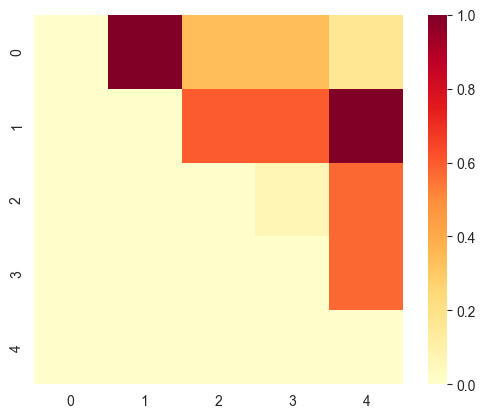

The average diversity of 5 MUSes generated by MARCO is: 0.5242857142857142


In [4]:
div_matrix = diversity_matrix(result, measure="overlap")
visualize_heatmap(div_matrix)
avg = div_matrix[np.triu_indices_from(div_matrix, k=1)].mean()
print(f"The average diversity of {len(result)} MUSes generated by MARCO is: {avg}")

In [5]:
for mus in result:
    display(visualize_constraints(mus, nurse_view, factory))

## 2 MARCO until diverse

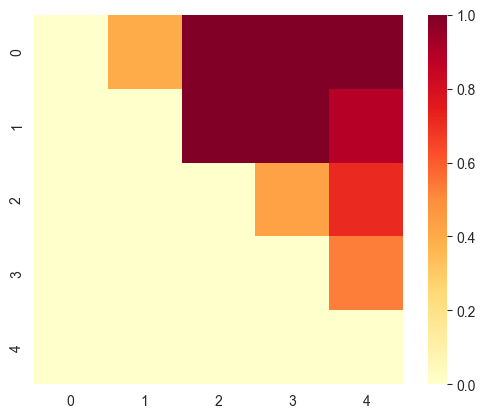

The average diversity of 5 most diverse MUSes generated by MARCO_until_diverse is: 0.7961157796451913


In [6]:
_, top_muses, total_time = marco_until_diverse(model.constraints, 5, time_limit=time_limit, solver="exact", map_solver="exact", return_mcs=False)
div_matrix = diversity_matrix(top_muses, measure="overlap")
visualize_heatmap(div_matrix)
avg = div_matrix[np.triu_indices_from(div_matrix, k=1)].mean()
print(f"The average diversity of {len(top_muses)} most diverse MUSes generated by MARCO_until_diverse is: {avg}")

In [7]:
for mus in top_muses:
    display(visualize_constraints(mus, nurse_view, factory))

## 3 D-MARCO (minimisation)

In [8]:
result = []
generator = marco_diverse_Min(model.constraints, solver="exact", map_solver="exact", return_mcs=False, time_limit=time_limit)
for status, subset, elapsed_time in generator:
    if status == "MUS":
        result.append(frozenset(subset))
        if len(result) >= 5:
            total_time = elapsed_time
            print(f"Found {len(result)} MUSes in {total_time:.2f} seconds")
            break
    else:
        print(f"Status: {status}, Time taken: {elapsed_time:.2f} seconds")

Found 5 MUSes in 0.73 seconds


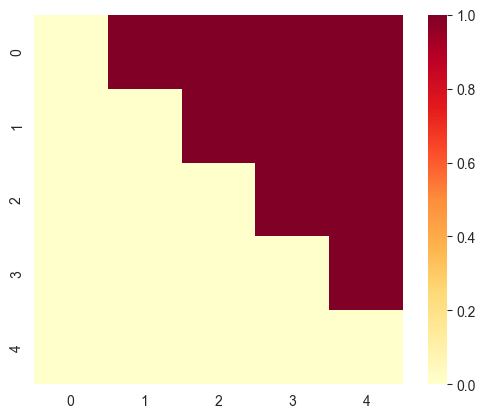

The average diversity of 5 first MUSes generated by D-MARCO (with minimisation) is: 1.0


In [9]:
div_matrix = diversity_matrix(result, measure="overlap")
visualize_heatmap(div_matrix)
avg = div_matrix[np.triu_indices_from(div_matrix, k=1)].mean()
print(f"The average diversity of {len(result)} first MUSes generated by D-MARCO (with minimisation) is: {avg}")

In [10]:
for mus in result:
    display(visualize_constraints(mus, nurse_view, factory))

## 4 D-MARCO (solution hinting)

In [11]:
result = []
generator = marco_diverse_noMin(model.constraints, solver="exact", map_solver="exact", return_mcs=False, time_limit=time_limit)
for status, subset, elapsed_time in generator:
    if status == "MUS":
        result.append(frozenset(subset))
        if len(result) >= 5:
            total_time = elapsed_time
            print(f"Found {len(result)} MUSes in {total_time:.2f} seconds")
            break
    else:
        print(f"Status: {status}, Time taken: {elapsed_time:.2f} seconds")

Found 5 MUSes in 0.71 seconds


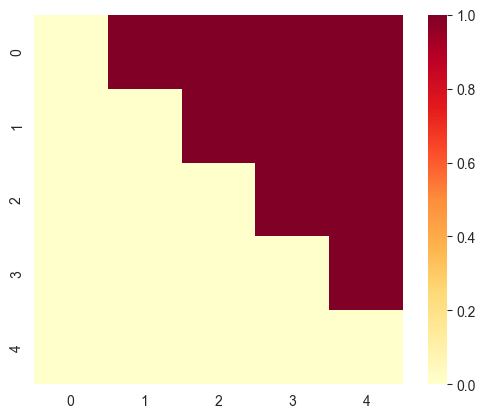

The average diversity of 5 first MUSes generated by D-MARCO (with solution hinting) is: 1.0


In [12]:
div_matrix = diversity_matrix(result, measure="overlap")
visualize_heatmap(div_matrix)
avg = div_matrix[np.triu_indices_from(div_matrix, k=1)].mean()
print(f"The average diversity of {len(result)} first MUSes generated by D-MARCO (with solution hinting) is: {avg}")

In [13]:
for mus in result:
    display(visualize_constraints(mus, nurse_view, factory))

# 5 D-OCUS (v1)

In [14]:
result = []
generator = ocus_enum_1(model.constraints, solver="exact", hs_solver="gurobi", time_limit=time_limit)
for status, subset, elapsed_time in generator:
    if status == "MUS":
        result.append(frozenset(subset))
        if len(result) >= 5:
            total_time = elapsed_time
            print(f"Found {len(result)} MUSes in {total_time:.2f} seconds")
            break
    else:
        print(f"Status: {status}, Time taken: {elapsed_time:.2f} seconds")

Status: TIMEOUT, Time taken: 60.02 seconds


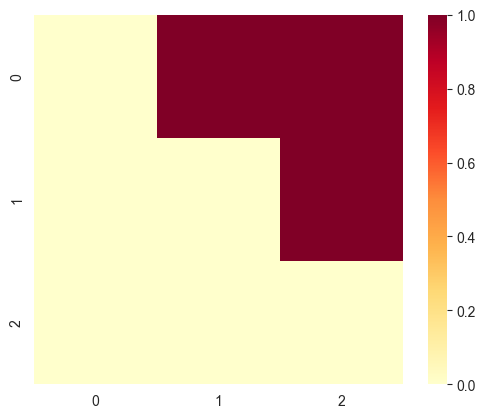

The average diversity of 3 first MUSes generated by D-OCUS (v1) is: 1.0


In [15]:
div_matrix = diversity_matrix(result, measure="overlap")
visualize_heatmap(div_matrix)
avg = div_matrix[np.triu_indices_from(div_matrix, k=1)].mean()
print(f"The average diversity of {len(result)} first MUSes generated by D-OCUS (v1) is: {avg}")

In [16]:
for mus in result:
    display(visualize_constraints(mus, nurse_view, factory))

## 6 D-OCUS (v2)

In [20]:
result = []
generator = ocus_enum_shrink(model.constraints, solver="exact", hs_solver="gurobi", time_limit=time_limit)
for status, subset, elapsed_time in generator:
    if status == "MUS":
        result.append(frozenset(subset))
        if len(result) >= 5:
            total_time = elapsed_time
            print(f"Found {len(result)} MUSes in {total_time:.2f} seconds")
            break
    else:
        print(f"Status: {status}, Time taken: {elapsed_time:.2f} seconds")

Found 5 MUSes in 1.50 seconds


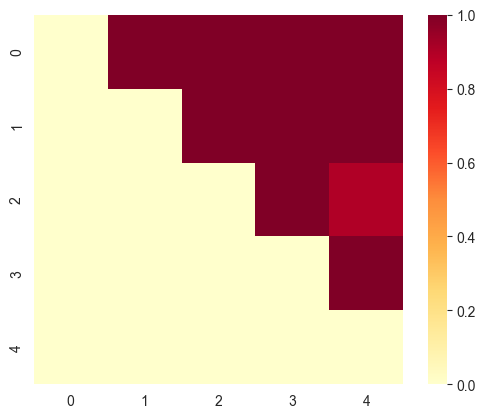

The average diversity of 5 first MUSes generated by D-OCUS(v2) is: 0.99


In [21]:
div_matrix = diversity_matrix(result, measure="overlap")
visualize_heatmap(div_matrix)
avg = div_matrix[np.triu_indices_from(div_matrix, k=1)].mean()
print(f"The average diversity of {len(result)} first MUSes generated by D-OCUS(v2) is: {avg}")

In [22]:
for mus in result:
    display(visualize_constraints(mus, nurse_view, factory))